<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/NLP/El%C5%91tan%C3%ADtott%20Modellek%20BERT%20%C3%A9s%20GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Előtanított NLP Modellek: BERT és GPT

**Licenc: CC BY-NC-SA 4.0**

Az **előtanított nyelvi modellek** (pre-trained language models) forradalmasították az NLP-t. Az ötlet: egyszer tanítjuk hatalmas szövegkorpuszon (Wikipedia, könyvek, internet), majd **finomhangoljuk** specifikus feladatokra.

## Transfer Learning az NLP-ben

```
                    Hatalmas korpusz           Kis címkézett adat
                         ↓                           ↓
[Pre-training] ──→ Általános nyelvtudás ──→ [Fine-tuning] ──→ Specifikus feladat
   (drága)              (reusable)               (olcsó)         (eredmény)
```

## Két fő paradigma

| | BERT | GPT |
|---|------|-----|
| **Típus** | Encoder-only | Decoder-only |
| **Irány** | Bidirectional | Autoregressive (left-to-right) |
| **Pre-training** | MLM + NSP | Next token prediction |
| **Downstream** | Klasszifikáció, NER, QA | Generálás, completion |
| **Kontextus** | Teljes mondat mindkét irányból | Csak korábbi tokenek |

## Tartalomjegyzék
1. BERT: Bidirectional Encoder
2. GPT: Autoregressive Decoder
3. Fine-tuning pipeline
4. Modell variánsok

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. BERT: Bidirectional Encoder Representations from Transformers

A BERT (Devlin et al., 2018) kétirányú kontextust használ, azaz minden token látja az összes többi tokent.

### Pre-training feladatok

#### Masked Language Modeling (MLM)
A bemeneti tokenek 15%-át véletlenszerűen **maszkoljuk**, és a modellnek ki kell találnia.

```
Input:  "A [MASK] ugat a [MASK]"
Output: "kutya", "kertben"
```

**Miért működik?** A modellnek meg kell értenie a kontextust mindkét irányból.

#### Next Sentence Prediction (NSP)
Két mondatról eldönti, követik-e egymást.

```
[CLS] A kutya alszik. [SEP] Nagyon fáradt volt. [SEP] → IsNext (1)
[CLS] A kutya alszik. [SEP] Párizsban esik az eső. [SEP] → NotNext (0)
```

### BERT tokenek

- **[CLS]**: Classification token (mondat reprezentáció)
- **[SEP]**: Separator (mondatok elválasztása)
- **[MASK]**: Maszkolt pozíció
- **[PAD]**: Padding

In [2]:
class SimpleBERT(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(512, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, n_layers)

        self.mlm_head = nn.Linear(d_model, vocab_size)  # MLM prediction
        self.cls_head = nn.Linear(d_model, 2)  # Classification

    def forward(self, x, task='mlm'):
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0)

        h = self.embedding(x) + self.pos_emb(pos)
        h = self.encoder(h)

        if task == 'mlm':
            return self.mlm_head(h)  # [B, L, vocab]
        else:
            return self.cls_head(h[:, 0])  # [CLS] token

bert = SimpleBERT(vocab_size=30000)
x = torch.randint(0, 30000, (2, 20))
print(f"MLM output: {bert(x, 'mlm').shape}")
print(f"CLS output: {bert(x, 'cls').shape}")

MLM output: torch.Size([2, 20, 30000])
CLS output: torch.Size([2, 2])


## 2. GPT: Generative Pre-trained Transformer

A GPT (Radford et al., 2018) autoregresszív modell: balról jobbra generál, mindig csak a korábbi tokeneket látva.

### Causal Language Modeling

```
Input:  "A kutya"     → Output: "ugat"
Input:  "A kutya ugat" → Output: "hangosan"
```

### Miért causal mask?

A generálásnál a modell **nem láthatja a jövőbeli tokeneket** - különben "csalhatna". A causal mask biztosítja, hogy minden pozíció csak a korábbi pozíciókat lássa.

### GPT változatok

| Modell | Paraméterek | Év |
|--------|-------------|-----|
| GPT-1 | 117M | 2018 |
| GPT-2 | 1.5B | 2019 |
| GPT-3 | 175B | 2020 |
| GPT-4 | ~1T (becsült) | 2023 |

In [3]:
class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(512, d_model)

        decoder_layer = nn.TransformerDecoderLayer(d_model, n_heads, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, n_layers)

        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        B, L = x.shape
        pos = torch.arange(L, device=x.device).unsqueeze(0)

        # Causal mask
        mask = torch.triu(torch.ones(L, L), diagonal=1).bool().to(x.device)

        h = self.embedding(x) + self.pos_emb(pos)
        h = self.decoder(h, h, tgt_mask=mask)

        return self.lm_head(h)

gpt = SimpleGPT(vocab_size=30000)
print(f"GPT output: {gpt(x).shape}")

GPT output: torch.Size([2, 20, 30000])


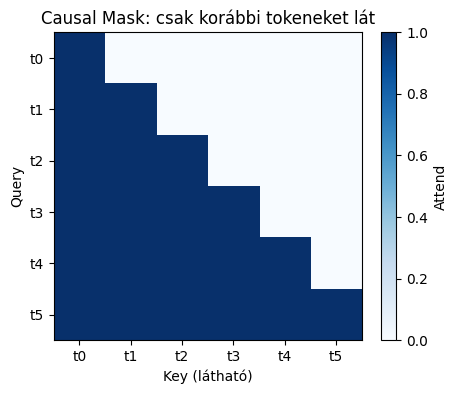

In [4]:
# Causal mask vizualizáció
L = 6
mask = torch.triu(torch.ones(L, L), diagonal=1)

plt.figure(figsize=(5, 4))
plt.imshow(1 - mask, cmap='Blues')
plt.xticks(range(L), [f't{i}' for i in range(L)])
plt.yticks(range(L), [f't{i}' for i in range(L)])
plt.xlabel('Key (látható)'); plt.ylabel('Query')
plt.title('Causal Mask: csak korábbi tokeneket lát')
plt.colorbar(label='Attend')
plt.show()

## 3. Fine-tuning pipeline

A fine-tuning során az előtanított modellt **specifikus feladatra hangoljuk**.

### Lépések

1. **Pre-trained modell betöltése** (pl. `bert-base-uncased`)
2. **Task-specific head** hozzáadása (Linear layer)
3. **Fine-tuning**: az egész modellt (vagy csak a head-et) tanítjuk

### Fine-tuning stratégiák

| Stratégia | Leírás | Mikor? |
|-----------|--------|--------|
| **Full fine-tuning** | Minden súly tanul | Sok adat, erős GPU |
| **Feature extraction** | Csak a head tanul | Kevés adat |
| **Gradual unfreezing** | Fokozatosan oldjuk fel a rétegeket | Közepes adat |
| **LoRA** | Kis adapter modulok | Hatékony fine-tuning |

### Learning rate

A fine-tuning-nál **kisebb learning rate** kell, mint a from-scratch tanulásnál:
- Pre-trained: ~2e-5 (BERT ajánlott)
- From-scratch: ~1e-3

In [5]:
# Hugging Face példa (pszeudokód)
print("""
from transformers import BertForSequenceClassification, Trainer

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

trainer = Trainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data
)
trainer.train()
""")


from transformers import BertForSequenceClassification, Trainer

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

trainer = Trainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data
)
trainer.train()



## 4. Modell variánsok és családok

### BERT család

| Modell | Különbség | Méret |
|--------|-----------|-------|
| **BERT-base** | Eredeti | 110M |
| **BERT-large** | Nagyobb | 340M |
| **RoBERTa** | Nincs NSP, több adat | 125M |
| **ALBERT** | Parameter sharing | 12M |
| **DistilBERT** | Disztillált, gyorsabb | 66M |
| **multilingual BERT** | 104 nyelv | 110M |

### GPT család

| Modell | Specialitás |
|--------|-------------|
| **GPT-2** | Nyílt forráskódú |
| **GPT-3** | In-context learning, API |
| **ChatGPT** | Dialogue fine-tuning (RLHF) |
| **GPT-4** | Multimodális (kép + szöveg) |

### Egyéb architektúrák

- **T5**: Text-to-Text (minden feladat → szöveg generálás)
- **BART**: Encoder-Decoder (denoising pre-training)
- **XLNet**: Permutációs nyelvi modell
- **ELECTRA**: Hatékony pre-training (replaced token detection)

## Összefoglalás

### Főbb tanulságok

1. **Pre-training + Fine-tuning**: A modern NLP alapja
2. **BERT**: Kétirányú kontextus, MLM pre-training → klasszifikáció, NER, QA
3. **GPT**: Autoregresszív generálás → szöveg completion, chatbot
4. **Transfer learning**: Kis adattal is jó eredmények az előtanított tudás miatt

### Mikor melyiket használd?

| Feladat | Ajánlott modell |
|---------|-----------------|
| Klasszifikáció | BERT, RoBERTa |
| NER (Named Entity Recognition) | BERT |
| Question Answering | BERT, ALBERT |
| Szöveg generálás | GPT-2, GPT-3 |
| Fordítás | T5, mBART |
| Összefoglalás | BART, T5 |
| Chatbot | ChatGPT, LLaMA |

### HuggingFace Hub

A legtöbb előtanított modell elérhető a [HuggingFace Hub](https://huggingface.co/models)-on:

```python
from transformers import AutoModel, AutoTokenizer

# Bármilyen modell betöltése
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")
```

### Következő lépések

A következő notebookban a **Question Answering** feladatot nézzük, ahol a BERT-et alkalmazzuk kérdés-válasz párok kezelésére!